# Introduction & Data Loading

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Simple Exponential Smoothing →](02_ses.ipynb)

This notebook loads five benchmark time series, visualises their structure, and introduces decomposition and autocorrelation as exploratory tools. Classical methods — as opposed to modern ML forecasters — assume explicit structure (trend, seasonality, autocorrelation) that we can diagnose visually and statistically.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')

## Datasets

We load five canonical series covering different frequencies and features.

In [2]:

# Load all five benchmark datasets
air = load_air_passengers()
milk = load_milk()
co2 = load_co2()
spots = load_sunspots()
retail = load_retail()

datasets = {
    'Air Passengers': air,
    'Milk Production': milk,
    'Mauna Loa CO2': co2,
    'Sunspots': spots,
    'UK Retail Sales': retail,
}
for name, s in datasets.items():
    freq = pd.infer_freq(s.index[:3]) if isinstance(s.index, pd.DatetimeIndex) else 'annual'
    print(f"{name:20s} n={len(s):4d}  freq={freq or 'irregular'}")


Air Passengers       n= 144  freq=MS
Milk Production      n= 168  freq=MS
Mauna Loa CO2        n= 526  freq=MS
Sunspots             n= 309  freq=annual
UK Retail Sales      n= 300  freq=MS


## Visualisation

Time plots reveal trend, seasonality, and changing variance at a glance.

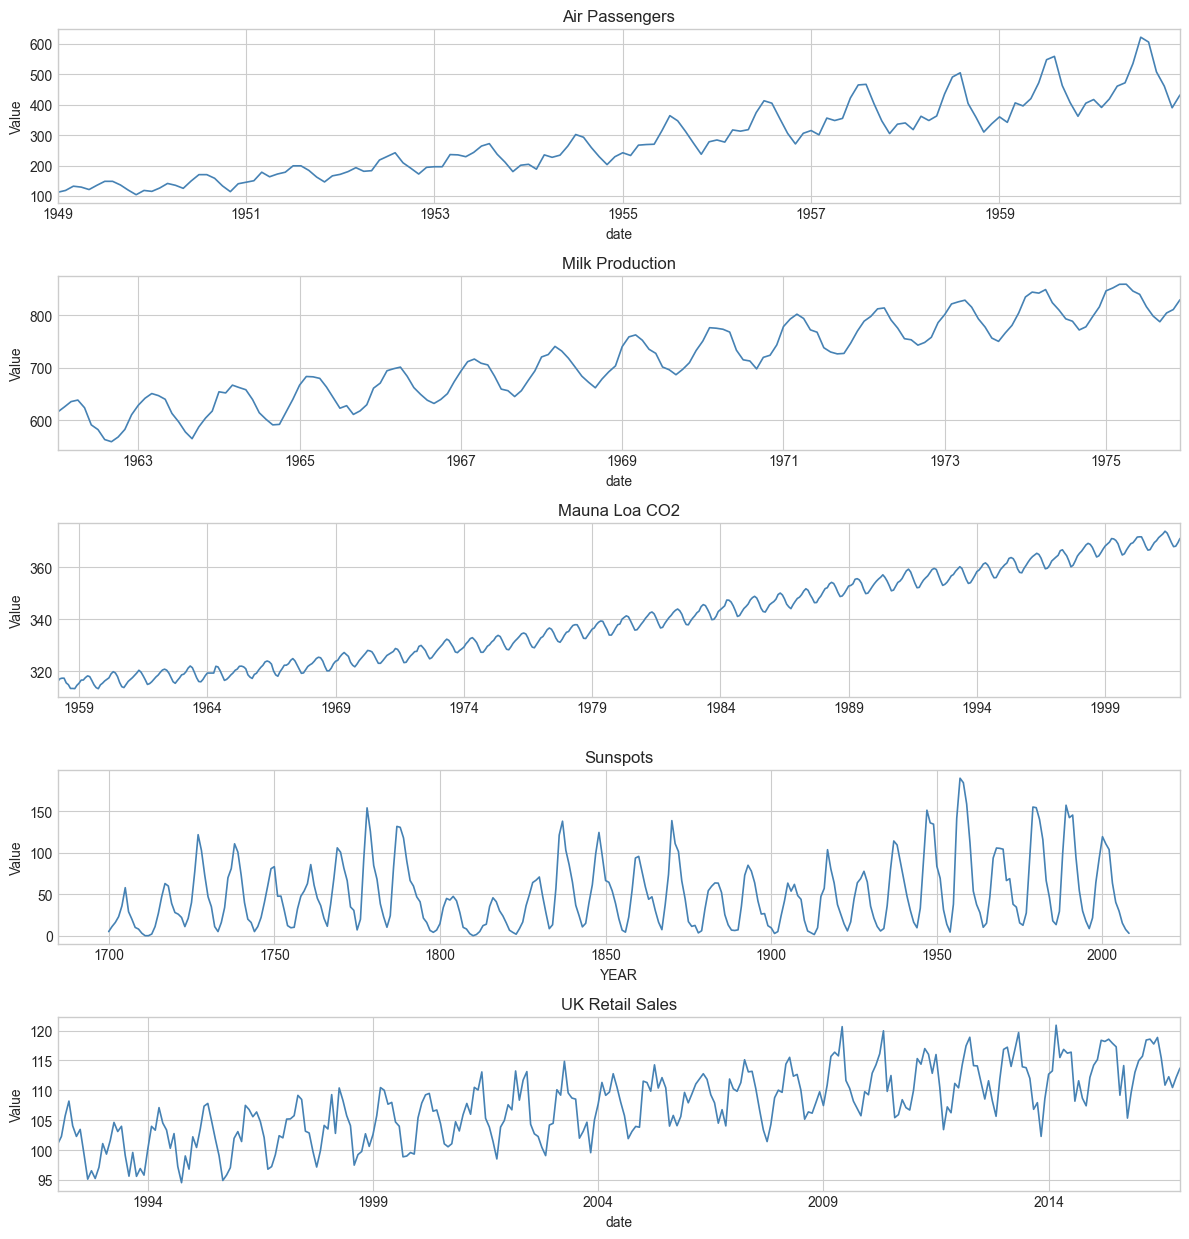

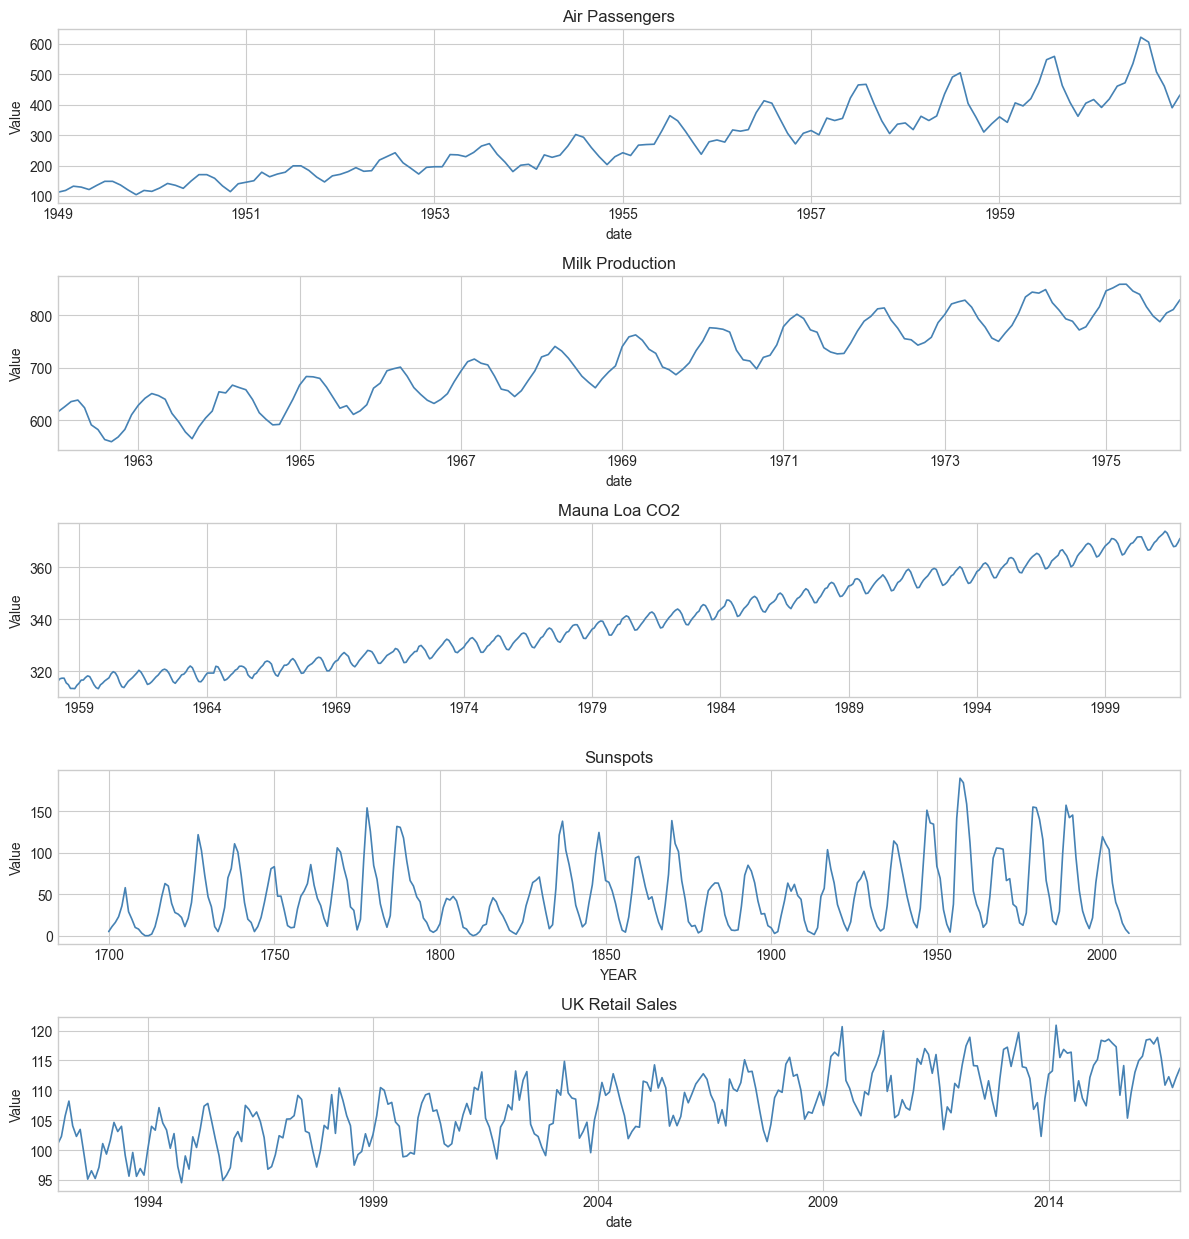

In [3]:

fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 2.5 * len(datasets)), sharex=False)
for ax, (name, s) in zip(axes, datasets.items()):
    s.plot(ax=ax, color='steelblue', lw=1.2)
    ax.set_title(name)
    ax.set_ylabel('Value')
fig.tight_layout()
fig


## Time Series Features

- **Trend**: long-run increase or decrease (Air Passengers, CO₂)
- **Seasonality**: fixed-period cycles (monthly period 12, annual period ~11 for sunspots)
- **Cyclicality**: non-fixed period oscillations
- **Irregularity**: noise and one-off events (UK Retail Sales)

Weak stationarity requires constant mean, constant variance, and autocovariance depending only on lag — rarely satisfied in raw economic series.

## Autocorrelation

ACF and PACF summarise linear dependence at each lag.

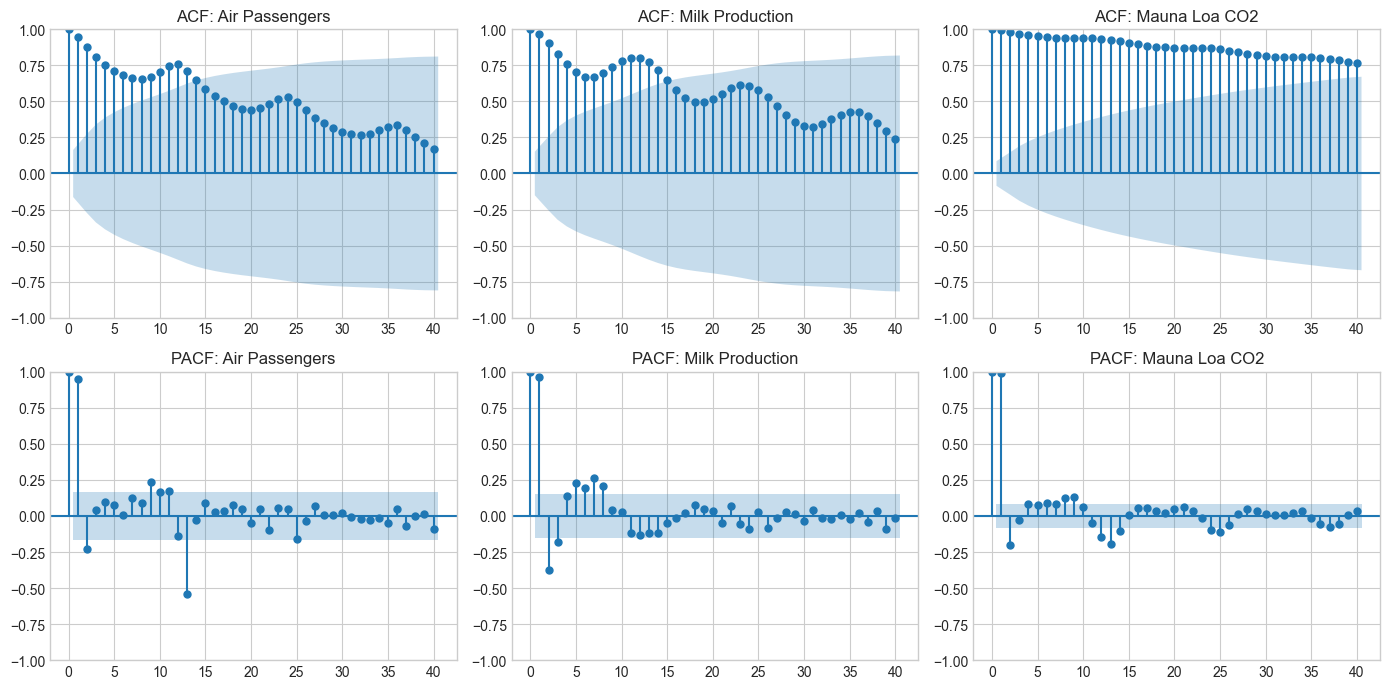

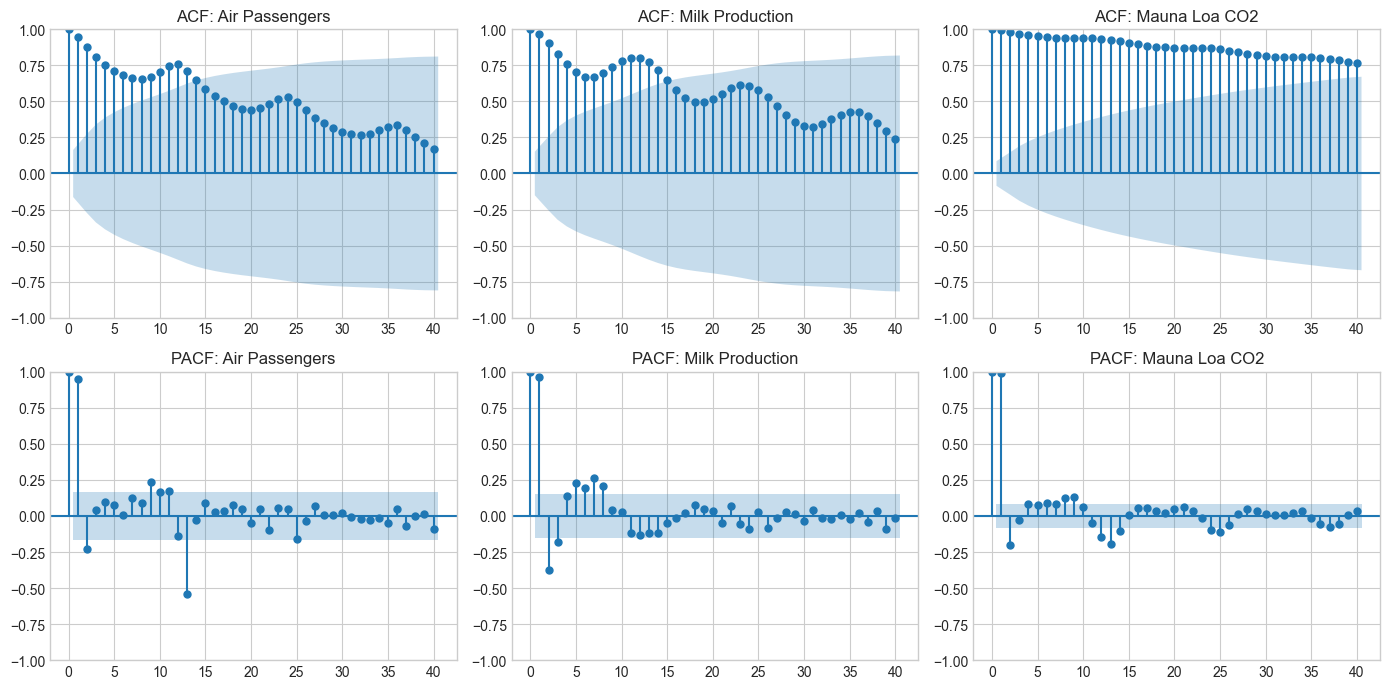

In [4]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
series_list = list(datasets.items())[:3]
for i, (name, s) in enumerate(series_list):
    plot_acf(s.dropna(), ax=axes[0, i], lags=min(40, len(s)//2 - 1), title=f'ACF: {name}')
    plot_pacf(s.dropna(), ax=axes[1, i], lags=min(40, len(s)//2 - 1), title=f'PACF: {name}', method='ywm')
fig.tight_layout()
fig


## Classical Decomposition

Additive: $y_t = T_t + S_t + R_t$. Multiplicative when seasonal amplitude grows with level.

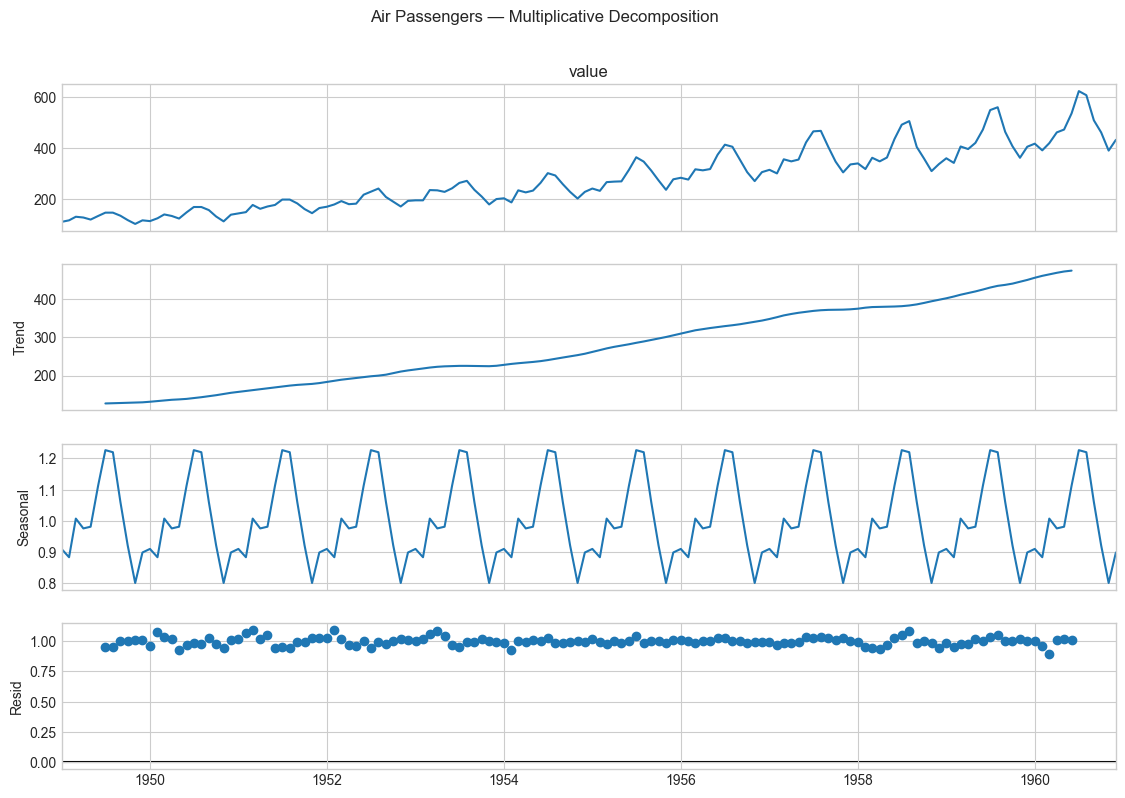

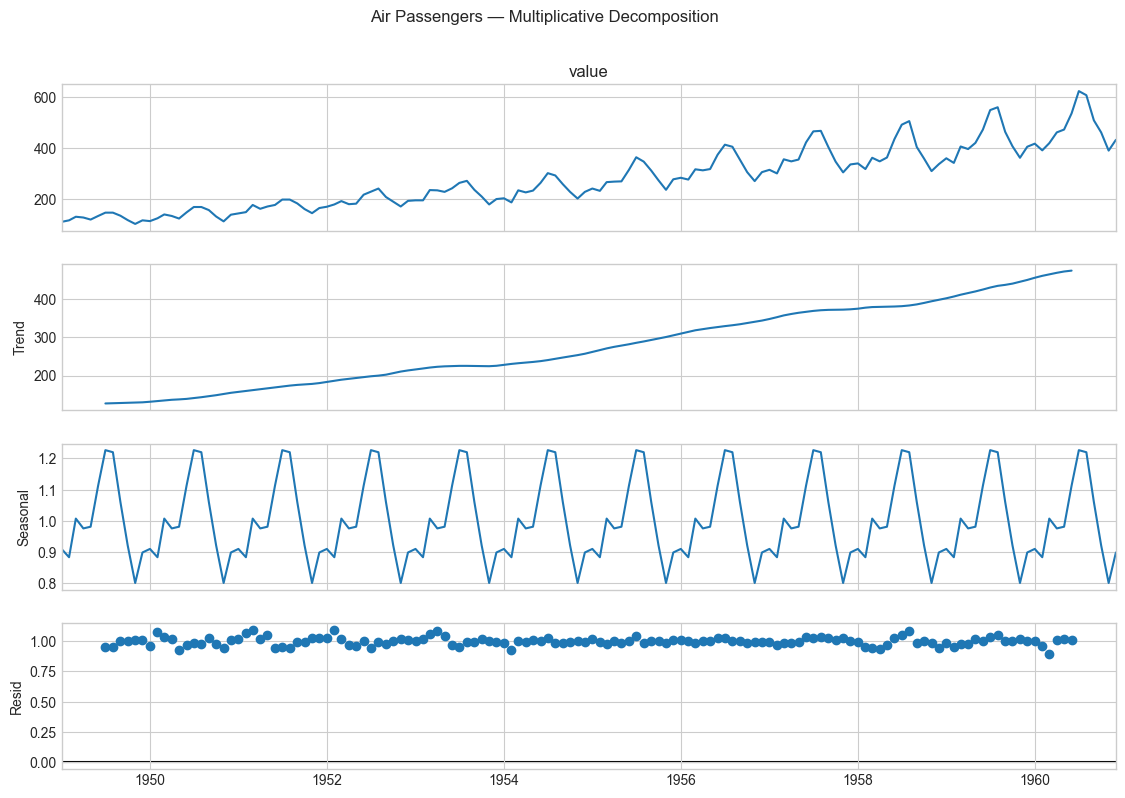

In [5]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Air Passengers — multiplicative seasonality
decomp_mul = seasonal_decompose(air, model='multiplicative', period=12)
fig = decomp_mul.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Air Passengers — Multiplicative Decomposition', y=1.02)
fig


## STL Decomposition

STL (Seasonal-Trend decomposition using Loess) is robust to outliers and handles evolving seasonality.

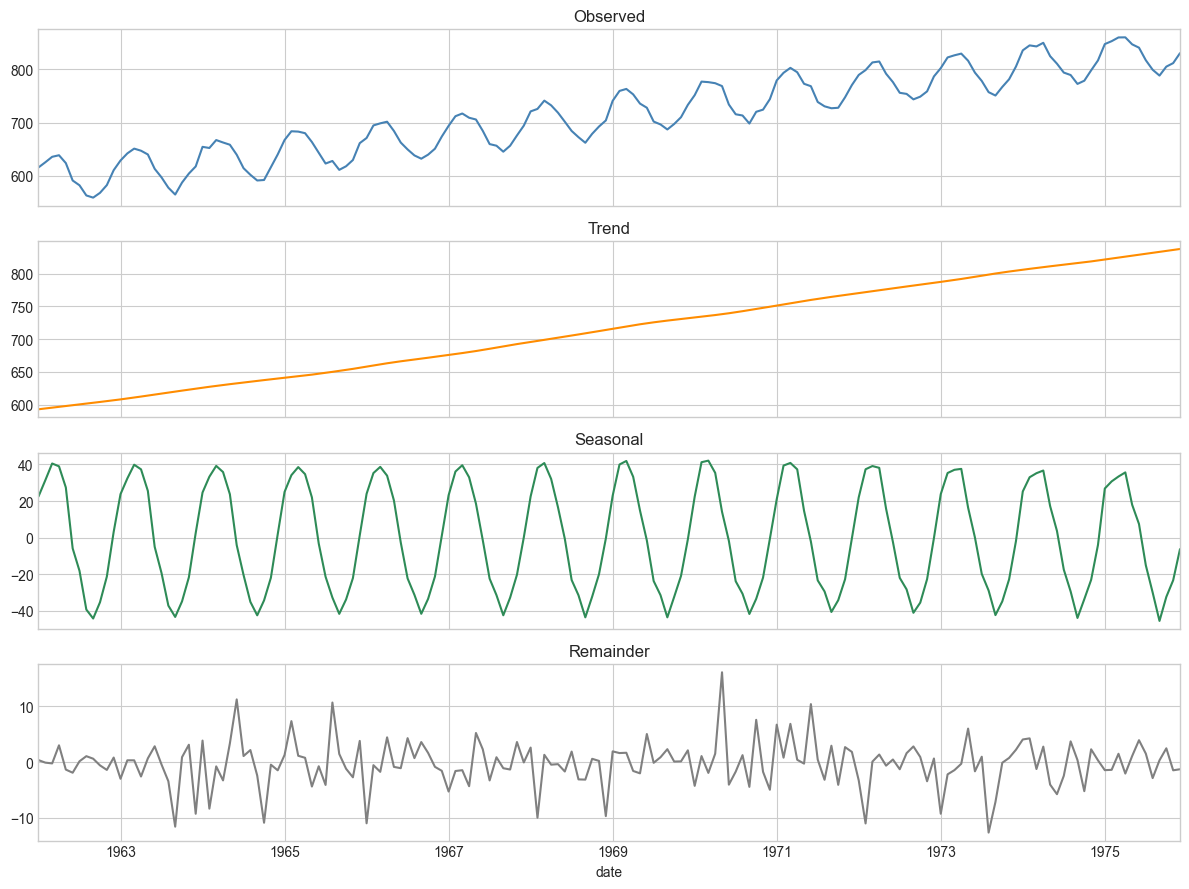

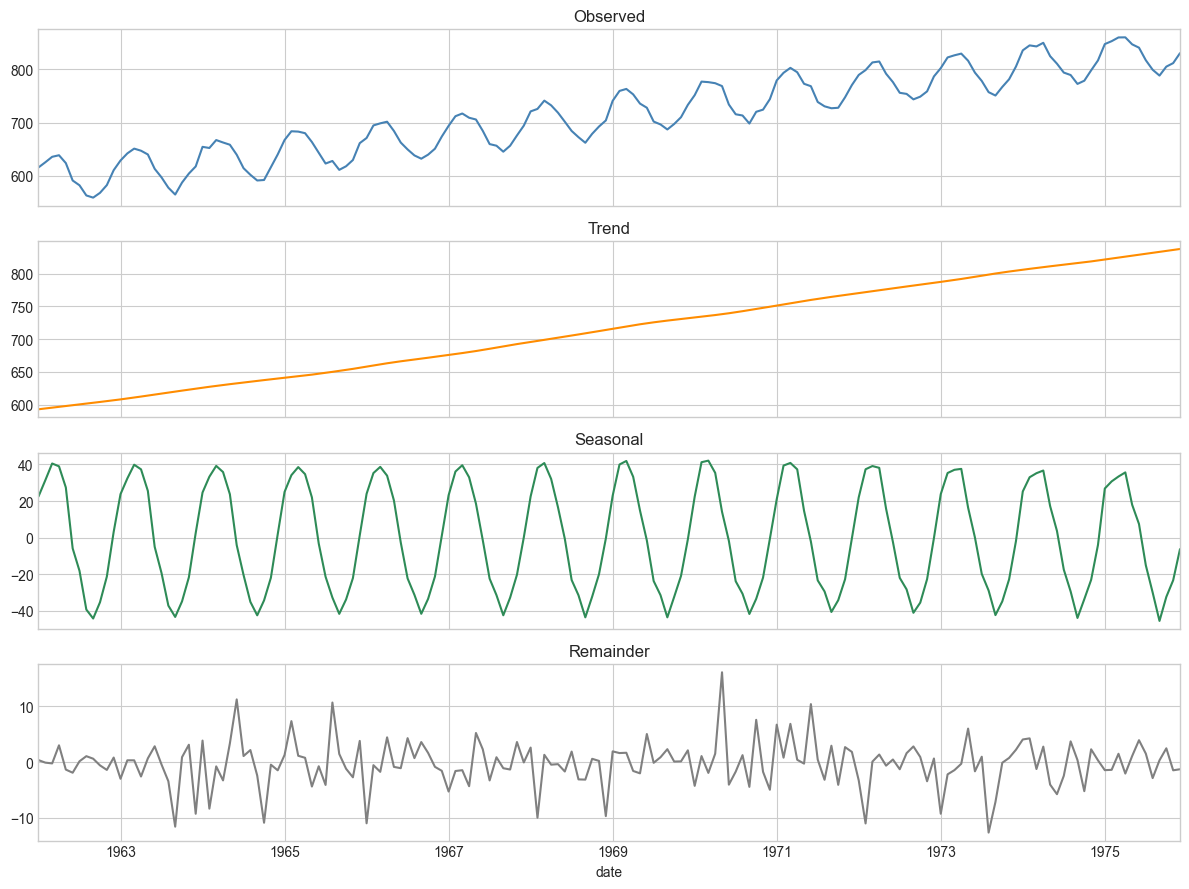

In [6]:

from statsmodels.tsa.seasonal import STL

stl = STL(milk, period=12, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
milk.plot(ax=axes[0], title='Observed', color='steelblue')
stl.trend.plot(ax=axes[1], title='Trend', color='darkorange')
stl.seasonal.plot(ax=axes[2], title='Seasonal', color='seagreen')
stl.resid.plot(ax=axes[3], title='Remainder', color='gray')
fig.tight_layout()
fig


## Key Takeaways

- **Benchmark diversity**: Each dataset highlights different features — multiplicative season (Air Passengers), additive season (Milk), quasi-periodicity (Sunspots), trend+season (CO₂), real-world noise (Retail).
- **ACF/PACF patterns**: Slow decay in ACF indicates non-stationarity; spikes at lag 12 signal monthly seasonality.
- **Decomposition choice**: Multiplicative when seasonal swings grow with level; STL preferred when outliers or evolving season matter.
- **Next steps**: With features identified, we proceed to modelling — starting with the simplest forecaster, SES.

---

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Simple Exponential Smoothing →](02_ses.ipynb)
